In [36]:
from typing import Dict, List
from model_ranking import (
    get_transformer_results_aug_sweep,
    extract_values_at_index,
    plot_performance_vs_transfer_metric,
)

In [37]:
selected_augmentations: Dict[str, List[str]] = {
    "none": [],
    "gauss": ["a001-002", "a002-003", "a003-004", "a004-005"],
}
source_models = {
    "Micro_SAM": ['vit_t_lm', 'vit_b_lm', 'vit_l_lm'],
    "Cellpose_SAM": ['cpsam'],
    # "BioImageIO": ["powerful_chipmunk"]
}
base_dir_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation"

In [38]:
SAM_direct_eval_results, SAM_p_eval_results, SAM_consis_results = get_transformer_results_aug_sweep(
    source_models=source_models,
    selected_augmentations=selected_augmentations,
    eval_key="mSA_scores_median",
    output_folder="percentiles_0_99",
    base_dir_path=base_dir_path,
)

In [39]:
SAM_consis_results

{'vit_t_lm': {'gauss': array([0.08694801, 0.20640387, 0.35794052, 0.5000174 ])},
 'vit_b_lm': {'gauss': array([0.03812425, 0.08505049, 0.13117361, 0.19440964])},
 'vit_l_lm': {'gauss': array([0.02669238, 0.06228989, 0.09518106, 0.12168119])},
 'cpsam': {'gauss': array([0.01102811, 0.01957979, 0.03347246, 0.04489069])}}

In [40]:
source_models = {
    "BioImageIO": ["powerful_chipmunk"]
}

In [42]:
BMZ_direct_eval_results, BMZ_p_eval_results, BMZ_consis_results = get_transformer_results_aug_sweep(
    source_models=source_models,
    selected_augmentations=selected_augmentations,
    eval_key="mSA_scores_median",
    output_folder="standardize2",
    base_dir_path=base_dir_path,
)

In [43]:
BMZ_consis_results

{'powerful_chipmunk': {'gauss': array([0.03690277, 0.04828427, 0.06607385, 0.06788921])}}

In [44]:
consis_results = {**SAM_consis_results, **BMZ_consis_results}
p_eval_results = {**SAM_p_eval_results, **BMZ_p_eval_results}
direct_eval_results = {**SAM_direct_eval_results, **BMZ_direct_eval_results}

In [45]:
consis_results

{'vit_t_lm': {'gauss': array([0.08694801, 0.20640387, 0.35794052, 0.5000174 ])},
 'vit_b_lm': {'gauss': array([0.03812425, 0.08505049, 0.13117361, 0.19440964])},
 'vit_l_lm': {'gauss': array([0.02669238, 0.06228989, 0.09518106, 0.12168119])},
 'cpsam': {'gauss': array([0.01102811, 0.01957979, 0.03347246, 0.04489069])},
 'powerful_chipmunk': {'gauss': array([0.03690277, 0.04828427, 0.06607385, 0.06788921])}}

Augmentation type: none
Augmentation type: gauss
  Index 0: Alpha a001-002


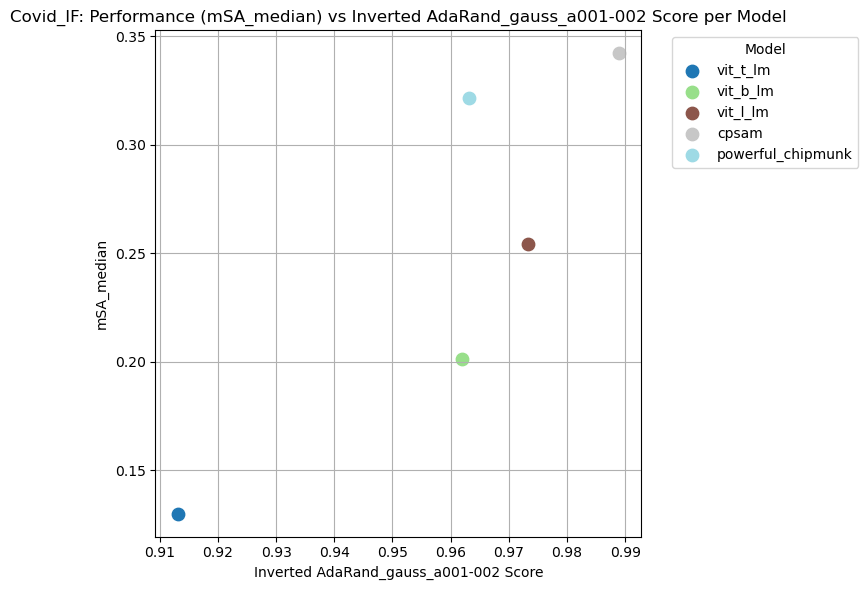

  Index 1: Alpha a002-003


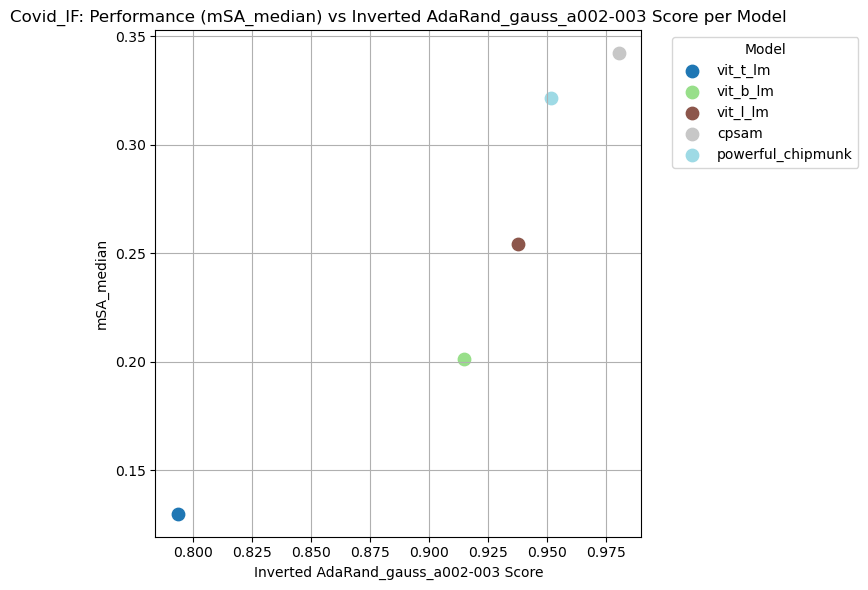

  Index 2: Alpha a003-004


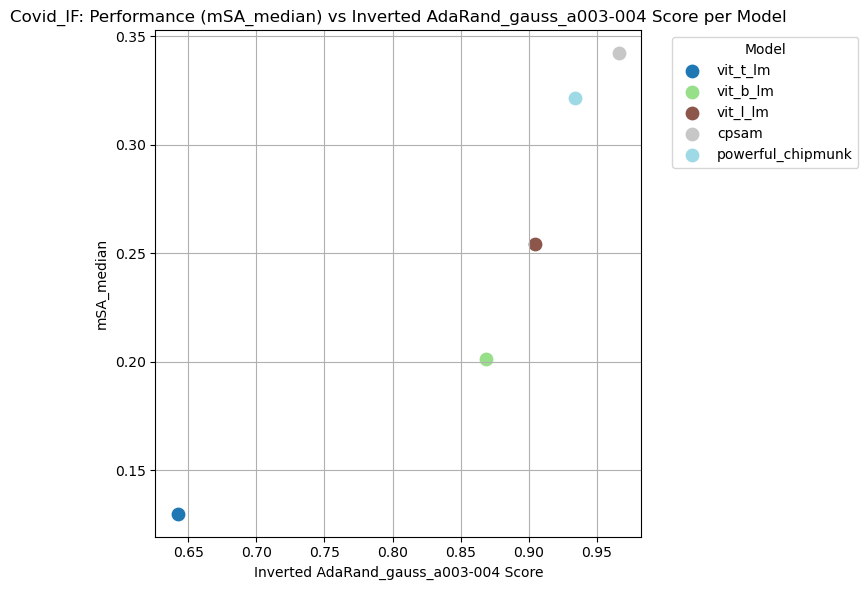

  Index 3: Alpha a004-005


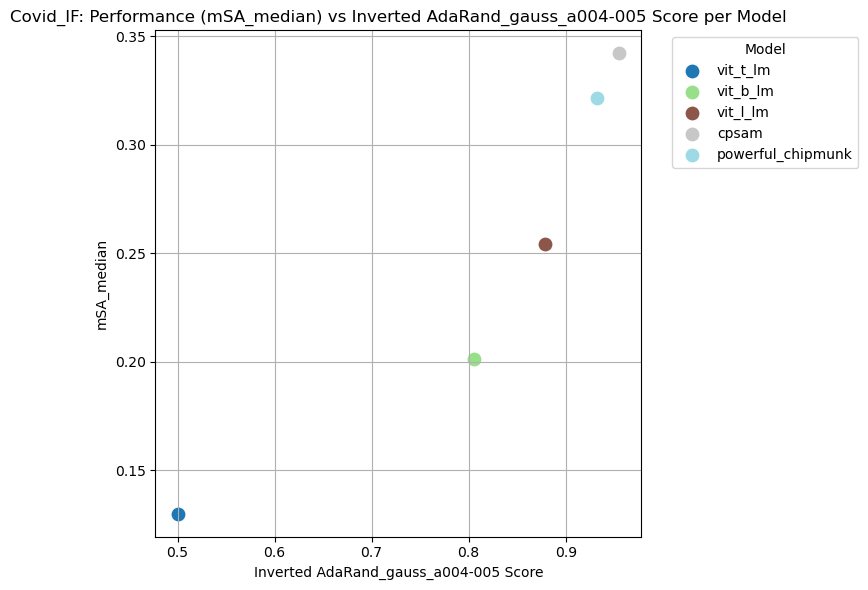

In [46]:
for aug_type, alphas in selected_augmentations.items():
    print(f"Augmentation type: {aug_type}")
    for i, alpha in enumerate(alphas):
        print(f"  Index {i}: Alpha {alpha}")

        consis_scores = extract_values_at_index(consis_results, aug_type, i)

        _ = plot_performance_vs_transfer_metric(
            performance_scores=direct_eval_results,
            transfer_metrics=consis_scores,
            target="Covid_IF",
            metric_name=f"Inverted AdaRand_{aug_type}_{alpha}",
            performance_metric_name="mSA_median",
            invert_transfer_metric=True,
        )

In [47]:
direct_eval_results

{'vit_t_lm': 0.1301584347117673,
 'vit_b_lm': 0.20151350376547836,
 'vit_l_lm': 0.25419152852487736,
 'cpsam': 0.34211604019208564,
 'powerful_chipmunk': 0.32150749427187775}

In [48]:
consis_scores

{'vit_t_lm': 0.5000174045562744,
 'vit_b_lm': 0.19440963864326477,
 'vit_l_lm': 0.12168119102716446,
 'cpsam': 0.044890690594911575,
 'powerful_chipmunk': 0.06788921356201172}

## Save Results

In [51]:
import json
import os
from typing import Any
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/transfer_results/ARE"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for aug_type, alphas in selected_augmentations.items():
    print(f"Augmentation type: {aug_type}")
    for i, alpha in enumerate(alphas):
        print(f"  Index {i}: Alpha {alpha}")

        consis_scores = extract_values_at_index(consis_results, aug_type, i)

        consis_scores_with_target = {"Covid_IF": consis_scores}


        with open(os.path.join(save_path, f"transfer_gauss_{alpha}_Forg_ARE_scores.json"), "w") as f:
            results: Dict[str, Any] = {
                "transfer_scores": convert_numpy_types(consis_scores_with_target),
            }
            json.dump(results, f, indent=4)

Augmentation type: none
Augmentation type: gauss
  Index 0: Alpha a001-002
  Index 1: Alpha a002-003
  Index 2: Alpha a003-004
  Index 3: Alpha a004-005


In [52]:
save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/transfer_results"
if not os.path.exists(save_path):
    os.makedirs(save_path)

performance_scores_with_target = {"Covid_IF": direct_eval_results}

with open(os.path.join(save_path, f"transfer_performance_MSA_scores.json"), "w") as f:
    results: Dict[str, Any] = {
        "performance_scores": convert_numpy_types(performance_scores_with_target),
    }
    json.dump(results, f, indent=4)